<a href="https://colab.research.google.com/github/Nastarii/MAFAUDA-Machine-fault-detection/blob/main/Machinery_Fault_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação dos dados

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uysalserkan/fault-induction-motor-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.41G/2.41G [00:39<00:00, 65.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/uysalserkan/fault-induction-motor-dataset/versions/1


In [ ]:
!ls $path

imbalance  normal


# Leitura dos dados

In [ ]:
from tqdm.notebook import tqdm
import pandas as pd
import os
from typing import List

def list_files(directory: str) -> List[str]:
    """
    Recursively lists all files in the given directory and its subdirectories.

    Args:
        directory (str): The path to the directory to list files from.

    Returns:
        List[str]: A list of file paths.
    """
    file_paths = []

    for root, _, filenames in os.walk(directory):
        for filename in filenames:
            file_paths.append(os.path.join(root, filename))

    return file_paths

def read_data(file_paths: List[str], folder_name: str) -> pd.DataFrame:
    """
    Reads and concatenates data from a list of file paths into a single DataFrame.

    Args:
        file_paths (List[str]): A list of file paths to read data from.
        folder_name (str): Folder Name to be read

    Returns:
        pd.DataFrame: A concatenated DataFrame containing data from all files.
    """
    df = pd.DataFrame()

    for file_path in tqdm(file_paths, folder_name):
      flag_df = pd.read_csv(file_path,header=None) # Read a single file
      df = pd.concat([df,flag_df],ignore_index=True) # Merge into our main dataframe

    return df

In [ ]:
# List files
imbalance_files_6g = list_files(f'{path}/imbalance/imbalance/6g')
imbalance_files_10g = list_files(f'{path}/imbalance/imbalance/10g')
imbalance_files_15g = list_files(f'{path}/imbalance/imbalance/15g')
imbalance_files_20g = list_files(f'{path}/imbalance/imbalance/20g')
imbalance_files_25g = list_files(f'{path}/imbalance/imbalance/25g')
imbalance_files_30g = list_files(f'{path}/imbalance/imbalance/30g')
imbalance_files_35g = list_files(f'{path}/imbalance/imbalance/35g')

normal_files = list_files(f'{path}/normal')

# Read files data
imbalance_data_6g = read_data(imbalance_files_6g, 'Imbalance 6g')
imbalance_data_10g = read_data(imbalance_files_10g, 'Imbalance 10g')
imbalance_data_15g = read_data(imbalance_files_15g, 'Imbalance 15g')
imbalance_data_20g = read_data(imbalance_files_20g, 'Imbalance 20g')
imbalance_data_25g = read_data(imbalance_files_25g, 'Imbalance 25g')
imbalance_data_30g = read_data(imbalance_files_30g, 'Imbalance 30g')
imbalance_data_35g = read_data(imbalance_files_35g, 'Imbalance 35g')

normal_data = read_data(normal_files, 'Normal')

Imbalance 6g:   0%|          | 0/49 [00:00<?, ?it/s]

Imbalance 10g:   0%|          | 0/48 [00:00<?, ?it/s]

Imbalance 15g:   0%|          | 0/48 [00:00<?, ?it/s]

Imbalance 20g:   0%|          | 0/49 [00:00<?, ?it/s]

Imbalance 25g:   0%|          | 0/47 [00:00<?, ?it/s]

Imbalance 30g:   0%|          | 0/47 [00:00<?, ?it/s]

Imbalance 35g:   0%|          | 0/45 [00:00<?, ?it/s]

Normal:   0%|          | 0/49 [00:00<?, ?it/s]

# Descrição do Dataset

Este banco de dados é composto por 1951 séries temporais multivariadas adquiridas por sensores em um Simulador de Falhas em Máquinas (MFS) da SpectraQuest, modelo Alignment-Balance-Vibration (ABVT).

Cada arquivo csv da base de dados representa uma sequência gerada a 50 KHz de taxa de amostragem durante 5 segundos, totalizando 250000 mil amostras.

As colunas do dataset representam:

**Coluna 1:**
Sinal do tacômetro que permite estimar a frequência de rotação.

**Colunas 2 a 4:**
Acelerômetro do mancal inferior (direções axial, radial e tangencial).

**Colunas 5 a 7:**
Acelerômetro do mancal superior (direções axial, radial e tangencial).

**Coluna 8:**
Microfone.

<ipython-input-12-ed031ac80a97>:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


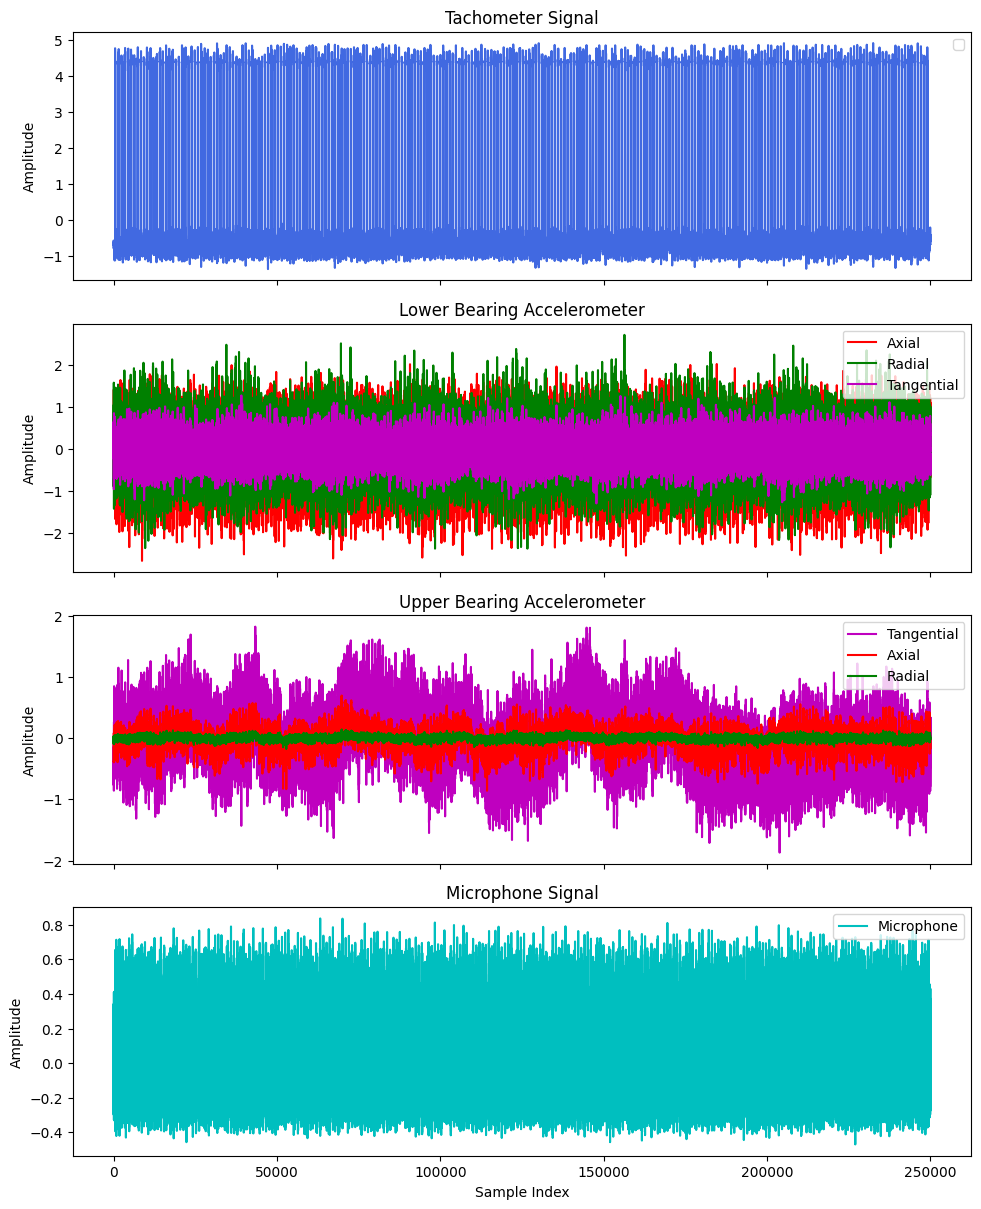

In [ ]:
import matplotlib.pyplot as plt

x = range(250000) # X range
samples = 250000 # Single Sequence Data

fig, axs = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

# Plotting the tachometer signal
axs[0].plot(x, normal_data[0][:250000].values, color='royalblue')
axs[0].set_title('Tachometer Signal')
axs[0].set_ylabel('Amplitude')
axs[0].legend()

# Plotting the lower bearing accelerometer (axial, radial, tangential)
axs[1].plot(x, normal_data[1][:250000].values, color='r', label='Axial')
axs[1].plot(x, normal_data[2][:250000].values, color='g', label='Radial')
axs[1].plot(x, normal_data[3][:250000].values, color='m', label='Tangential')
axs[1].set_title('Lower Bearing Accelerometer')
axs[1].set_ylabel('Amplitude')
axs[1].legend()

# Plotting the upper bearing accelerometer (axial, radial, tangential)
axs[2].plot(x, normal_data[6][:250000].values, color='m', label='Tangential')
axs[2].plot(x, normal_data[4][:250000].values, color='r', label='Axial')
axs[2].plot(x, normal_data[5][:250000].values, color='g', label='Radial')
axs[2].set_title('Upper Bearing Accelerometer')
axs[2].set_ylabel('Amplitude')
axs[2].legend()

# Plotting the microphone signal
axs[3].plot(x, normal_data[7][:250000].values, color='c', label='Microphone')
axs[3].set_title('Microphone Signal')
axs[3].set_ylabel('Amplitude')
axs[3].legend()

# Layout adjustments
plt.tight_layout()
plt.xlabel('Sample Index')
plt.show()

In [ ]:
normal_data.shape, imbalance_data_6g.shape

((12250000, 8), (12250000, 8))

# Distribuição das classes

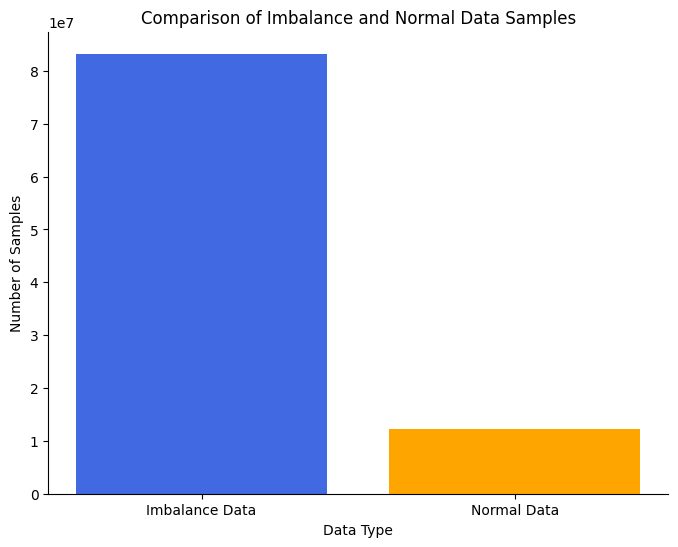

In [ ]:
import matplotlib.pyplot as plt
# Calculate the total number of samples for imbalance data
total_imbalance_samples = (
    imbalance_data_6g.shape[0] +
    imbalance_data_10g.shape[0] +
    imbalance_data_15g.shape[0] +
    imbalance_data_20g.shape[0] +
    imbalance_data_25g.shape[0] +
    imbalance_data_30g.shape[0] +
    imbalance_data_35g.shape[0]
)

# Get the number of samples for normal data
total_normal_samples = normal_data.shape[0]

# Create labels and values for the plot
labels = ['Imbalance Data', 'Normal Data']
values = [total_imbalance_samples, total_normal_samples]

# Plot the comparison
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Remove top and left spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(labels, values, color=['royalblue', 'orange'])
plt.title('Comparison of Imbalance and Normal Data Samples')
plt.xlabel('Data Type')
plt.ylabel('Number of Samples')
plt.show()

# Pré-processamento

Foram aplicados três tipos de pré-processamento no dataset:

**1º Down Sampling:** Esta técnica foi escolhida devido à alta taxa de amostragem dos dados (50 kHz), que pode resultar em informações redundantes, tornando o processamento mais lento e demandando maior consumo de memória ao trabalhar com essa taxa.
- *Implementação:* A principal vantagem de usar a função scipy.signal.decimate para o down sampling é que ela aplica automaticamente um filtro anti-aliasing para prevenir a distorção do sinal durante o downsampling. O aliasing ocorre quando altas frequências não são corretamente representadas devido à redução da taxa de amostragem.
- *Impacto:* O downsampling reduz a taxa de amostragem de um sinal, o que diminui o volume de dados e pode melhorar a eficiência computacional. No entanto, pode levar à perda de informações detalhadas.

**2º Transformada de Fourier Rápida (FFT):** A FFT transforma sinais de vibração do domínio do tempo para o domínio da frequência, permitindo identificar padrões ocultos e detectar anomalias em máquinas e equipamentos. Como falhas mecânicas, como desbalanceamento, geram vibrações em frequências características, a FFT facilita a análise ao destacar picos em frequências específicas.
- *Implementação:* A FFT pega o sinal original e tenta descobrir quais ondas senoidais foram misturadas para criá-lo. Para isso, ela "compara" o sinal com várias ondas de diferentes frequências e mede o quanto cada frequência contribui para formar o sinal original.
Esse processo é realizado de forma eficiente utilizando convoluções discretas, onde o sinal é multiplicado por funções senoidais e somado ao longo do tempo.
- *Impacto:* A operação da FFT destaca as frequências dominantes, permitindo separar componentes úteis do sinal. No entanto, a principal limitação da FFT é que ela perde informações temporais.

**3º Undersampling:** Esta técnica foi escolhida devido ao desbalanceamento das classes, onde a classe majoritária possui um número excessivo de amostras, o que pode afetar o desempenho do modelo.

- *Implementação:* O undersampling equilibra as classes, melhorando a performance de algoritmos sensíveis a dados desbalanceados, ao reduzir a classe majoritária e evitar viés.

- *Impacto:* O undersampling pode melhorar o desempenho, mas pode resultar na perda de informações importantes da classe majoritária, prejudicando a capacidade do modelo de aprender representações completas.

In [ ]:
from scipy.signal import decimate
import numpy as np

def down_sample(df: pd.DataFrame, factor: int, zero_phase: bool = True) -> pd.DataFrame:
    """
    Applies downsampling to a DataFrame using scipy.signal.decimate.

    Parameters:
    - df: Input DataFrame, where rows represent time series points.
    - factor: Downsampling factor (e.g., factor=10 reduces the size to 1/10 of the original).
    - zero_phase: If True, uses zero-phase filtering to minimize distortion.

    Returns:
    - A new downsampled DataFrame.
    """
    # Apply decimate to each column separately
    downsampled_data = np.apply_along_axis(decimate, axis=0, arr=df.values, q=factor, zero_phase=zero_phase)

    # Create a new DataFrame with the same column names
    df_downsampled = pd.DataFrame(downsampled_data, columns=df.columns)

    return df_downsampled

In [ ]:
from scipy import signal

def compute_fft(data):
    """
    Compute the Fast Fourier Transform (FFT) using convolution.

    Parameters:
    data (array-like): Input data for which FFT is to be computed.

    Returns:
    pd.DataFrame: A DataFrame containing the autocorrelation result.
    """
    autocorr = signal.fftconvolve(data, data[::-1], mode='full')
    return pd.DataFrame(autocorr)

In [ ]:
def under_sampling(df: pd.DataFrame, num_sequences=49, sequence_length=5000, seed=42) -> pd.DataFrame:
    """
    Performs under-sampling on a DataFrame by randomly selecting a specified number of sequences
    of a fixed length (in terms of rows) and returning a DataFrame containing only these sequences.

    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data to be sampled.

    num_sequences(int): The number of sequences to be randomly selected from the DataFrame. (Normal data has 49 sequences)

    sequence_length(int): The length of each selected sequence. Each sequence has 5000 length because (250000 samples reduced by 50 factor)

    seed(int):The seed for the random number generator, ensuring reproducibility of the results.

    Returns:
     df (pd.DataFrame):A DataFrame containing the randomly selected sequences, with a total of `num_sequences`.

    """
    # Set the seed for reproducibility
    np.random.seed(seed)

    # Determine the total number of sequences based on the sequence length
    total_sequences = len(df) // sequence_length

    # Randomly select the starting indices of the sequences (multiples of sequence_length)
    sequence_indices = np.random.choice(np.arange(0, total_sequences) * sequence_length, size=num_sequences, replace=False)

    under_sampled_df = pd.DataFrame()

    # Loop through the selected sequence indices
    for idx in sequence_indices:
        # Select the rows corresponding to the current sequence (5000 rows)
        sequence = df.iloc[idx : idx + sequence_length]  # Corrected line
        under_sampled_df = pd.concat([under_sampled_df, sequence], ignore_index=True)  # Merge into our main dataframe

    return under_sampled_df

In [ ]:
# Downsample imbalance data
down_sampled_imbalance_6g = down_sample(imbalance_data_6g, 50)
down_sampled_imbalance_10g = down_sample(imbalance_data_10g, 50)
down_sampled_imbalance_15g = down_sample(imbalance_data_15g, 50)
down_sampled_imbalance_20g = down_sample(imbalance_data_20g, 50)
down_sampled_imbalance_25g = down_sample(imbalance_data_25g, 50)
down_sampled_imbalance_30g = down_sample(imbalance_data_30g, 50)
down_sampled_imbalance_35g = down_sample(imbalance_data_35g, 50)
down_sampled_normal = down_sample(normal_data, 50)

In [ ]:
down_sampled_imbalance = pd.concat([
    down_sampled_imbalance_6g,
    down_sampled_imbalance_10g,
    down_sampled_imbalance_15g,
    down_sampled_imbalance_20g,
    down_sampled_imbalance_25g,
    down_sampled_imbalance_30g,
    down_sampled_imbalance_35g
], ignore_index=True)

In [ ]:
under_sampled_imbalance_data = under_sampling(down_sampled_imbalance)

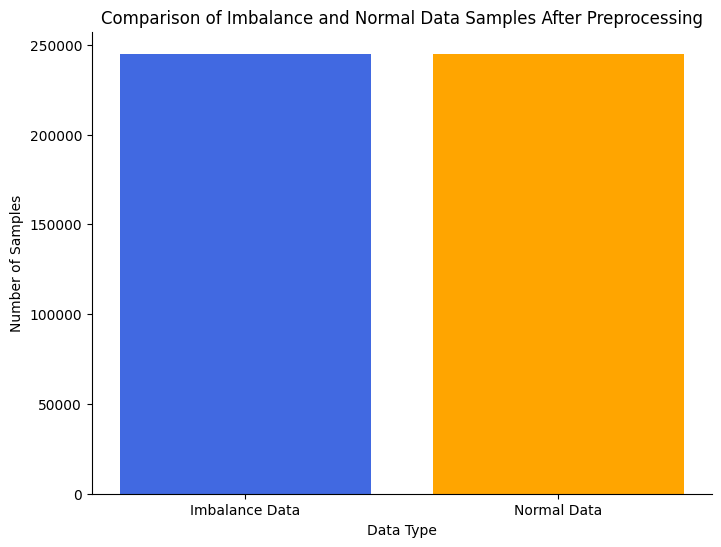

In [ ]:
import matplotlib.pyplot as plt

# Create labels and values for the plot
labels = ['Imbalance Data', 'Normal Data']
values = [under_sampled_imbalance_data.shape[0], down_sampled_normal.shape[0]]

# Plot the comparison
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Remove top and left spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(labels, values, color=['royalblue', 'orange'])
plt.title('Comparison of Imbalance and Normal Data Samples After Preprocessing')
plt.xlabel('Data Type')
plt.ylabel('Number of Samples')
plt.show()

In [ ]:
under_sampled_imbalance_data.to_csv('imbalance_data_preprocess.csv', index=False)
down_sampled_normal.to_csv('normal_data_preprocess.csv', index=False)

In [ ]:
import pandas as pd

under_sampled_imbalance_data = pd.read_csv('/content/drive/MyDrive/Semeq/imbalance_data_preprocess.csv')
down_sampled_normal = pd.read_csv('/content/drive/MyDrive/Semeq/normal_data_preprocess.csv')

## Extração de características com a FFT

In [ ]:
# FFT Computation
fft_imbalance = compute_fft(under_sampled_imbalance_data)
fft_normal = compute_fft(down_sampled_normal)

## Rotulação do dataset

In [ ]:
import numpy as np

X = pd.concat([fft_normal,fft_imbalance],ignore_index=True)
y = pd.concat([
    pd.DataFrame(np.zeros(int(len(fft_normal)),dtype=int)), # Define normal as 0
    pd.DataFrame(np.ones(int(len(fft_imbalance)),dtype=int)) # Define imbalance as 1
], ignore_index=True)

## Reorganização do dataset

Preparação necessária para inserir os dados no modelo de séries temporais

In [ ]:
# Reshape data for Conv1D model (samples, timesteps, features)
X = X.values.reshape(X.shape[0], 1, X.shape[1])
y = y.values.reshape(y.shape[0], 1, y.shape[1])

## Separação de treino e teste

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True)

In [ ]:
print("Shape of Train Data : {}".format(X_train.shape))
print("Shape of Test Data : {}".format(X_test.shape))

Shape of Train Data : (734998, 1, 15)
Shape of Test Data : (245000, 1, 15)


# Definição do modelo

O modelo escolhido para a execução da atividade foi a rede neural **Conv1D**.

A Conv1D é ideal para dados sequenciais como séries temporais, que são comuns em aplicações de monitoramento de vibração.
- *Vantagens:* Ela é capaz de capturar padrões locais nos dados de vibração, como falhas específicas que ocorrem em certas janelas de tempo.

- *Limitações:* Embora a Conv1D seja eficaz para capturar padrões locais, ela tem dificuldade em modelar relações temporais de longo prazo. Além disso, como a Conv1D é uma rede supervisionada, ela requer um conjunto grande de dados rotulados para treinar adequadamente

## Treinamento e Validação

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# Define the 1D CNN model
model = Sequential([
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=1),
    Conv1D(filters=128, kernel_size=1, activation='relu'),
    MaxPooling1D(pool_size=1),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])


# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'AUC'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
22969/22969 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step - AUC: 0.9696 - accuracy: 0.9461 - loss: 0.9316 - val_AUC: 0.9988 - val_accuracy: 0.9918 - val_loss: 0.0300
Epoch 2/10
22969/22969 ━━━━━━━━━━━━━━━━━━━━ 83s 2ms/step - AUC: 0.9986 - accuracy: 0.9904 - loss: 0.0406 - val_AUC: 0.9993 - val_accuracy: 0.9935 - val_loss: 0.0249
Epoch 3/10
22969/22969 ━━━━━━━━━━━━━━━━━━━━ 82s 2ms/step - AUC: 0.9991 - accuracy: 0.9933 - loss: 0.0278 - val_AUC: 0.9988 - val_accuracy: 0.9932 - val_loss: 0.0440
Epoch 4/10
22969/22969 ━━━━━━━━━━━━━━━━━━━━ 49s 2ms/step - AUC: 0.9992 - accuracy: 0.9939 - loss: 0.0280 - val_AUC: 0.9994 - val_accuracy: 0.9952 - val_loss: 0.0207
Epoch 5/10
22969/22969 ━━━━━━━━━━━━━━━━━━━━ 87s 2ms/step - AUC: 0.9990 - accuracy: 0.9938 - loss: 0.0343 - val_AUC: 0.9993 - val_accuracy: 0.9956 - val_loss: 0.0194
Epoch 6/10
22969/22969 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - AUC: 0.9990 - accuracy: 0.9940 - loss: 0.0309 - val_AUC: 0.9985 - val_accuracy: 0.9939 - val_loss: 0.0284
Epoch 7/10

## Visualização dos Resultados

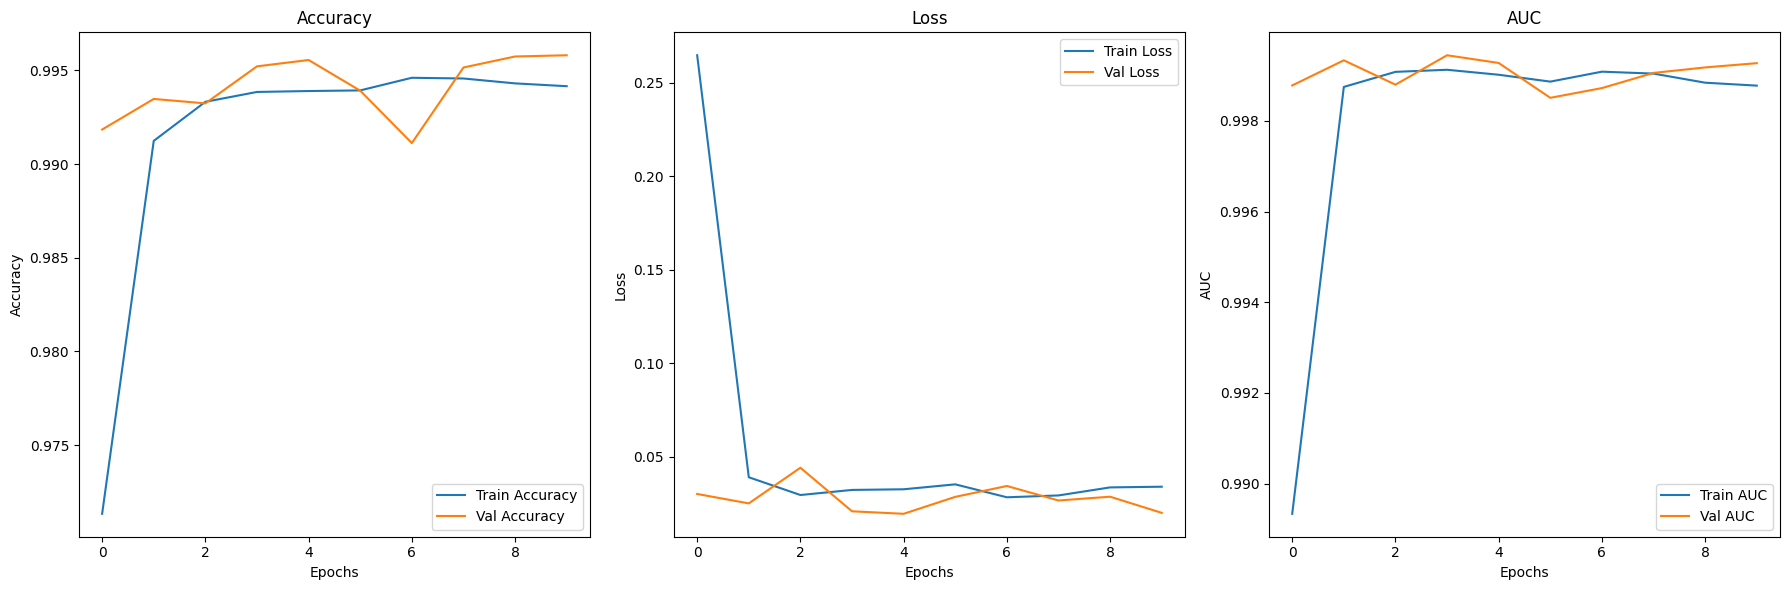

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(18, 6))

# Accuracy plot
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# AUC plot
plt.subplot(1, 3, 3)
plt.plot(history.history['AUC'], label='Train AUC')
plt.plot(history.history['val_AUC'], label='Val AUC')
plt.title('AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

# Possiveis limitações

A Conv1D (Rede Neural Convolucional 1D) é uma excelente escolha para tarefas de classificação de séries temporais, sendo um modelo bastante eficaz para identificar padrões locais nos dados sequenciais. No entanto, para problemas mais complexos, como o de classificação binária, existem diversas abordagens que podem melhorar ainda mais o desempenho.

Uma estratégia poderosa é combinar CNNs com redes neurais recorrentes (RNNs), como LSTM ou GRU. Essa combinação permite que o modelo capture tanto os padrões locais das séries temporais (através da CNN) quanto as dependências de longo prazo (via RNN). Um exemplo seria usar camadas Conv1D para extrair as características iniciais e, em seguida, camadas LSTM ou GRU para modelar as relações temporais mais distantes.

Outra opção interessante são os Transformers, que, apesar de terem sido inicialmente desenvolvidos para tarefas de NLP, demonstram grande eficácia também em séries temporais. Seu mecanismo de atenção permite que o modelo capture dependências de longo alcance nos dados. O uso de um codificador Transformer com atenção multi-cabeça pode ser vantajoso para identificar padrões globais importantes nas séries temporais.